# Neutrino Oscillation Explorer — PMNS + NSI

**Drag sliders to see how NSI parameters deform the oscillation probabilities at NOvA / DUNE / T2K geometry.**

- **Main view**: P(νμ→νe) appearance and P(νμ→νμ) disappearance vs energy.
- **NSI sliders**: off-diagonal ε parameters (v1 — diagonals fixed to zero).
- **Reference overlay**: dashed gray = NSI=0 standard PMNS curve.
- **3×3 grid**: toggle to see all nine P(να→νβ) channels.

In [17]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib
matplotlib.use('widget')   # interactive backend for JupyterLab
import matplotlib.pyplot as plt
import ipywidgets as w
from IPython.display import display

from nuosclab import PMNSParams, NSIParams, ExplorerConfig, compute_curves
from nuosclab.plotting import (
    make_two_panel_figure, make_3x3_figure,
    update_two_panel, update_3x3,
)

N_POINTS = 400

In [18]:
# ── PDG-2024 defaults ──────────────────────────────────────────────────────
_PDG = dict(
    th12    = np.degrees(PMNSParams().th12),
    th13    = np.degrees(PMNSParams().th13),
    th23    = np.degrees(PMNSParams().th23),
    dm21    = PMNSParams().dm21,
    dm32    = PMNSParams().dm31 - PMNSParams().dm21,
    delta_cp = PMNSParams().delta_cp,
)

# ── Experiment preset selector ─────────────────────────────────────────────
w_preset = w.ToggleButtons(
    options=['NOvA', 'DUNE', 'T2K'],
    value='NOvA',
    description='Experiment:',
    button_style='',
    style={'description_width': 'initial'},
)

# ── Mode toggles ────────────────────────────────────────────────────────────
w_anti    = w.ToggleButton(value=False, description='Antineutrino mode',
                           button_style='info', layout=w.Layout(width='180px'))
w_ref     = w.ToggleButton(value=True,  description='Reference overlay (NSI=0)',
                           button_style='', layout=w.Layout(width='210px'))
w_grid    = w.ToggleButton(value=False, description='Show full 3×3 grid',
                           button_style='', layout=w.Layout(width='170px'))

# ── PMNS sliders ────────────────────────────────────────────────────────────
slider_kw = dict(style={'description_width': '60px'}, layout=w.Layout(width='380px'))

w_th12    = w.FloatSlider(value=_PDG['th12'],   min=20., max=45.,   step=0.1,  description='θ₁₂ (°)',  **slider_kw)
w_th13    = w.FloatSlider(value=_PDG['th13'],   min=5.,  max=15.,   step=0.05, description='θ₁₃ (°)',  **slider_kw)
w_th23    = w.FloatSlider(value=_PDG['th23'],   min=35., max=55.,   step=0.1,  description='θ₂₃ (°)',  **slider_kw)
w_dm21    = w.FloatSlider(value=_PDG['dm21']*1e5, min=6., max=9.,   step=0.01, description='Δm²₂₁ (×10⁻⁵ eV²)', style={'description_width': '160px'}, layout=w.Layout(width='460px'))
w_dm32    = w.FloatSlider(value=_PDG['dm32']*1e3, min=2., max=3.,   step=0.005, description='Δm²₃₂ (×10⁻³ eV²)', style={'description_width': '160px'}, layout=w.Layout(width='460px'))
w_dcp     = w.FloatSlider(value=np.degrees(_PDG['delta_cp']), min=-180., max=180., step=1., description='δ_CP (°)', **slider_kw)

btn_reset_pmns = w.Button(description='Reset PMNS to PDG', button_style='warning',
                           layout=w.Layout(width='180px'))

# ── NSI sliders ─────────────────────────────────────────────────────────────
nsi_kw = dict(style={'description_width': '80px'}, layout=w.Layout(width='380px'))

w_eps_emu    = w.FloatSlider(value=0., min=0., max=0.5,  step=0.005, description='|ε_eμ|',    **nsi_kw)
w_eps_etau   = w.FloatSlider(value=0., min=0., max=0.5,  step=0.005, description='|ε_eτ|',   **nsi_kw)
w_eps_mutau  = w.FloatSlider(value=0., min=0., max=0.5,  step=0.005, description='|ε_μτ|',   **nsi_kw)
w_del_emu    = w.FloatSlider(value=0., min=-np.pi, max=np.pi, step=0.05, description='δ_eμ (rad)', **nsi_kw)
w_del_etau   = w.FloatSlider(value=0., min=-np.pi, max=np.pi, step=0.05, description='δ_eτ (rad)', **nsi_kw)
w_del_mutau  = w.FloatSlider(value=0., min=-np.pi, max=np.pi, step=0.05, description='δ_μτ (rad)', **nsi_kw)

btn_reset_nsi = w.Button(description='Reset NSI', button_style='warning',
                          layout=w.Layout(width='120px'))

def _reset_pmns(_):
    w_th12.value  = _PDG['th12']
    w_th13.value  = _PDG['th13']
    w_th23.value  = _PDG['th23']
    w_dm21.value  = _PDG['dm21'] * 1e5
    w_dm32.value  = _PDG['dm32'] * 1e3
    w_dcp.value   = np.degrees(_PDG['delta_cp'])
btn_reset_pmns.on_click(_reset_pmns)

def _reset_nsi(_):
    for sl in (w_eps_emu, w_eps_etau, w_eps_mutau, w_del_emu, w_del_etau, w_del_mutau):
        sl.value = 0.0
btn_reset_nsi.on_click(_reset_nsi)

In [19]:
# ── Figure setup ─────────────────────────────────────────────────────────────
fig2, axes2 = make_two_panel_figure(figsize=(11, 4))
fig3, axes3 = make_3x3_figure(figsize=(13, 9))
fig3.canvas.layout.display = 'none'

out2 = w.Output()

with out2:
    display(fig2.canvas)

# ── Redraw callback ──────────────────────────────────────────────────────────
def _redraw(*_):
    pmns = PMNSParams(
        th12     = np.radians(w_th12.value),
        th13     = np.radians(w_th13.value),
        th23     = np.radians(w_th23.value),
        dm21     = w_dm21.value * 1e-5,
        dm31     = (w_dm32.value * 1e-3) + (w_dm21.value * 1e-5),
        delta_cp = np.radians(w_dcp.value),
    )
    nsi = NSIParams(
        eps_emu     = w_eps_emu.value,
        eps_etau    = w_eps_etau.value,
        eps_mutau   = w_eps_mutau.value,
        delta_emu   = w_del_emu.value,
        delta_etau  = w_del_etau.value,
        delta_mutau = w_del_mutau.value,
    )

    curves = compute_curves(ExplorerConfig(
        experiment=w_preset.value,
        pmns=pmns,
        nsi=nsi,
        antineutrino=w_anti.value,
        n_points=N_POINTS,
        include_standard=w_ref.value,
        include_nominal=False,
    ))

    update_two_panel(axes2, curves.energy_gev, curves.live, curves.standard,
                     curves.preset, curves.config.antineutrino)
    fig2.canvas.draw_idle()

    if w_grid.value:
        update_3x3(axes3, curves.energy_gev, curves.live, curves.standard,
                   curves.preset, curves.config.antineutrino)
        fig3.canvas.draw_idle()


# Observe all widgets
_all_widgets = [
    w_preset, w_anti, w_ref, w_grid,
    w_th12, w_th13, w_th23, w_dm21, w_dm32, w_dcp,
    w_eps_emu, w_eps_etau, w_eps_mutau,
    w_del_emu, w_del_etau, w_del_mutau,
]
for ww in _all_widgets:
    ww.observe(_redraw, names='value')

def _toggle_grid(change):
    if change['new']:
        fig3.canvas.layout.display = None
        _redraw()  # populate it
    else:
        fig3.canvas.layout.display = 'none'
w_grid.observe(_toggle_grid, names='value')

Output()

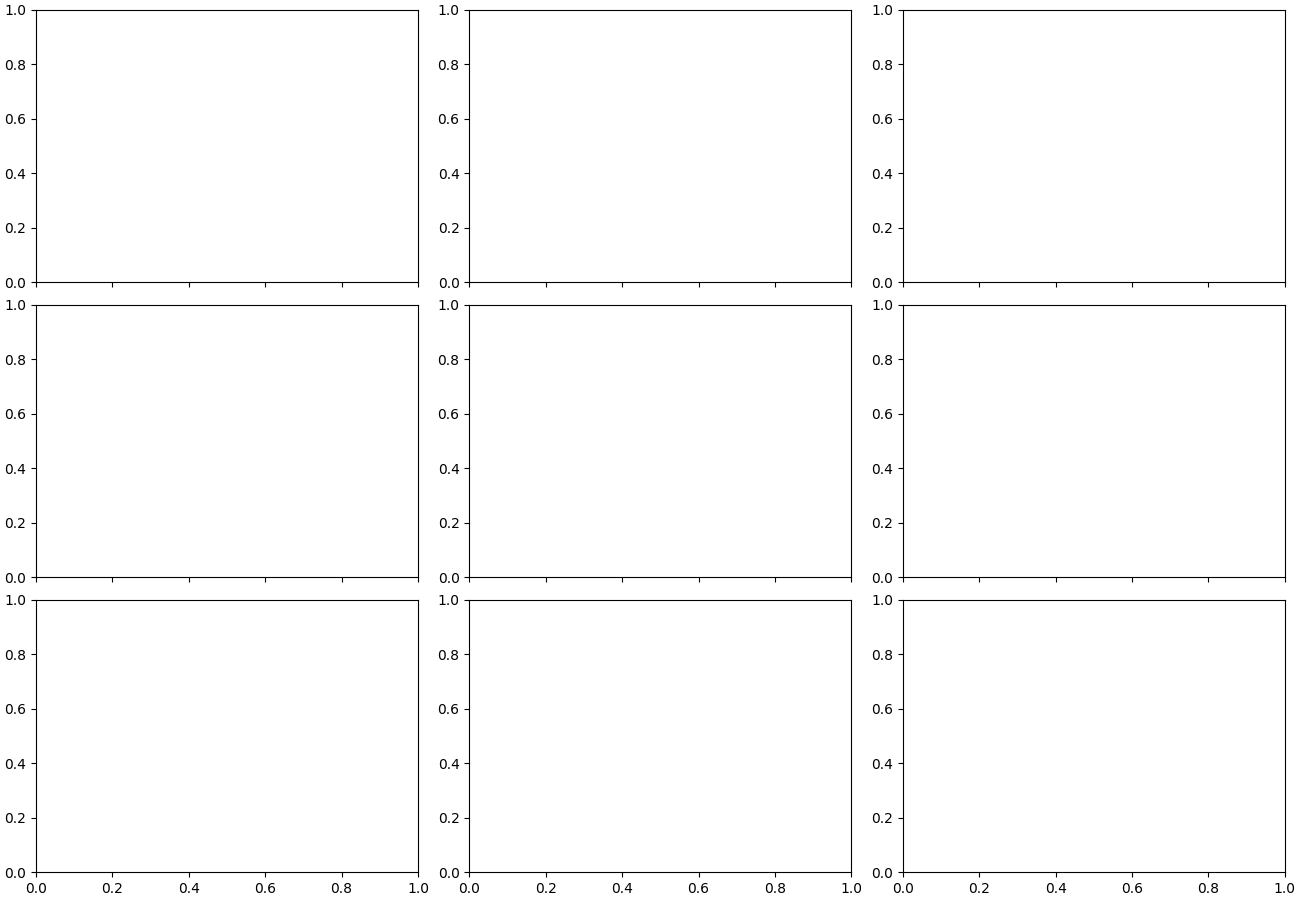

In [20]:
# ── Layout and display ────────────────────────────────────────────────────────

header = w.HBox([w_preset, w_anti, w_ref, w_grid])

pmns_box = w.VBox([
    w.HTML('<b>PMNS parameters</b>'),
    w.HBox([w_th12, w_th13]),
    w.HBox([w_th23, w_dcp]),
    w.HBox([w_dm21, w_dm32]),
    btn_reset_pmns,
], layout=w.Layout(border='1px solid #ddd', padding='8px', margin='4px'))

nsi_box = w.VBox([
    w.HTML('<b>NSI parameters</b> (off-diagonal ε; all zero = standard PMNS)'),
    w.HBox([w_eps_emu, w_del_emu]),
    w.HBox([w_eps_etau, w_del_etau]),
    w.HBox([w_eps_mutau, w_del_mutau]),
    btn_reset_nsi,
], layout=w.Layout(border='1px solid #fca', padding='8px', margin='4px'))

controls = w.VBox([header, pmns_box, nsi_box])

display(controls, out2, fig3.canvas)
_redraw()   # draw the initial state